# Gamma sensitivity analysis

For each of the four return metrics (actor/absolute x episode/discounted return), final performance vs. `gamma`, one line per budget variant (5 fixed budgets + the adaptive[1-5] budget), with a shaded 95% CI band across seeds.

`absolute` is the post-training "absolute metric" (see `stoix/evaluator.py`): the best checkpoint re-evaluated for 10x as many episodes as a single eval step, logged once per run rather than as a training curve - a much less noisy final-performance estimate than the per-checkpoint `evaluator/*` curve, so it's used here in place of `evaluator/*`.

Requires a wandb cache CSV fetched with the updated `fetch_wandb_lightsout_hd64.py` (the one that exports `gamma` and `absolute/*` columns) and spanning more than one `gamma` value - currently only `wandb_cache_hd64-lightsout-icot-final.csv` (Transformer-CoT, gamma in {0.99, 0.995, 0.999, 0.9995}) qualifies.

In [1]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import seaborn as sns

import analysis_utils as base

set_size = base.set_size
pgf_with_latex = base.pgf_with_latex
doc_width_pt = base.doc_width_pt

plt.rcParams.update(pgf_with_latex)

sns.set_palette("colorblind")

CI95_Z = 1.96  # normal-approximation 95% CI half-width, in units of SEM
N_TAIL_EVALS = 3  # matches compute_final_values' n_tail elsewhere in this repo

CSV_PATH = "wandb_cache_hd64-lightsout-icot-final.csv"
ARCH = None  # None = use whichever single arch is present in the CSV
TRIM_N = 0  # drop this many highest- and lowest-performing seeds per (budget, gamma) group before averaging


In [2]:
df = pd.read_csv(CSV_PATH)
df = df[df["state"] == "finished"]
df = df[~df["sgh"]]

missing = [c for c in ("gamma", "absolute/episode_return/mean") if c not in df.columns]
if missing:
    raise ValueError(
        f"{CSV_PATH} is missing {missing} - re-fetch it with the updated fetch_wandb_lightsout_hd64.py"
    )
df = df[df["gamma"].notna()]

if ARCH is None:
    archs = df["arch"].unique()
    if len(archs) != 1:
        raise ValueError(f"Multiple architectures present ({list(archs)}) - set ARCH explicitly")
    ARCH = archs[0]
df = df[df["arch"] == ARCH]

gammas = sorted(df["gamma"].unique())
print(f"arch={ARCH}, gammas={gammas}, seeds={df['seed'].nunique()}")

arch=Transformer-CoT, gammas=[0.99, 0.995, 0.999, 0.9995], seeds=10


In [3]:
def budget_label(min_steps, max_steps):
    return f"uniform={min_steps}" if min_steps == max_steps else f"adaptive[{min_steps}-{max_steps}]"


def compute_final_values(sub, metric, n_tail=N_TAIL_EVALS):
    """Per-run final performance: mean of the last n_tail eval points, plus
    the run's budget/gamma so it can be grouped on afterward."""
    tail = sub.sort_values("eval_idx").groupby("run_id").tail(n_tail)
    return (
        tail.groupby("run_id")
        .agg(
            value=(metric, "mean"),
            min_steps=("min_steps", "first"),
            max_steps=("max_steps", "first"),
            gamma=("gamma", "first"),
        )
        .reset_index()
    )


def _trim_by_performance(g: pd.DataFrame, trim: int) -> pd.DataFrame:
    """Drops the `trim` lowest- and `trim` highest-value seeds from a
    (budget, gamma) group, for a trimmed mean/CI robust to one or two
    outlier seeds. No-op if there aren't enough seeds left over (need more
    than 2*trim to begin with)."""
    if trim <= 0 or len(g) <= 2 * trim:
        return g
    return g.sort_values("value").iloc[trim : len(g) - trim]


def gamma_curves(sub, metric, trim=0):
    """{budget_label: DataFrame[gamma, mean, ci]} for one metric, across
    every (min_steps, max_steps) budget present in `sub`. `trim` drops the
    `trim` highest- and lowest-performing seeds from each (budget, gamma)
    group before averaging (a trimmed mean/CI - see _trim_by_performance),
    so one or two outlier seeds don't dominate a group of only ~10."""
    final = compute_final_values(sub, metric)
    curves = {}
    budgets = sorted(
        final[["min_steps", "max_steps"]].drop_duplicates().itertuples(index=False, name=None),
        key=lambda mm: (mm[0] != mm[1], mm[0], mm[1]),
    )
    for mn, mx in budgets:
        g = final[(final["min_steps"] == mn) & (final["max_steps"] == mx)]
        rows = []
        for gamma_val, gg in g.groupby("gamma"):
            gg = _trim_by_performance(gg, trim)
            n = len(gg)
            mean = gg["value"].mean()
            ci = CI95_Z * gg["value"].std() / np.sqrt(n) if n > 1 else 0.0
            rows.append({"gamma": gamma_val, "mean": mean, "ci": ci, "n": n})
        stats = pd.DataFrame(rows).sort_values("gamma")
        curves[budget_label(mn, mx)] = stats
    return curves

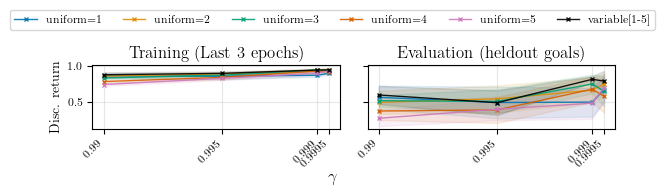

In [4]:
# episode_discounted_return, episode_return, episode_length, compute_time
METRIC_TO_PLOT = "episode_discounted_return"
# METRIC_TO_PLOT = "episode_return"
# METRIC_TO_PLOT = "episode_length"
# METRIC_TO_PLOT = "compute_time"

if METRIC_TO_PLOT == "episode_discounted_return":
    Y_LABEL = "Disc. return"
elif METRIC_TO_PLOT == "episode_return":
    Y_LABEL = "Undisc. return"
elif METRIC_TO_PLOT == "episode_length":
    Y_LABEL = "Episode length"
elif METRIC_TO_PLOT == "compute_time":
    Y_LABEL = "Compute time"
else:
    raise NotImplementedError

METRIC_PANELS = [
    ("actor", f"actor/{METRIC_TO_PLOT}/mean"),
    ("absolute", f"absolute/{METRIC_TO_PLOT}/mean"),
]

all_budget_labels = sorted(
    {
        budget_label(mn, mx)
        for mn, mx in df[["min_steps", "max_steps"]].drop_duplicates().itertuples(index=False)
    },
    key=lambda b: (b.startswith("adaptive"), b),
)
palette = dict(zip(all_budget_labels, sns.color_palette("colorblind", n_colors=len(all_budget_labels))))
palette["adaptive[1-5]"] = (0.0, 0.0, 0.0)

nrows = 1
ncols = 2

figsize = set_size(doc_width_pt, fraction=0.95, subplots=(nrows, ncols), use_golden_ratio=True)
fig, axes = plt.subplots(nrows, ncols, figsize=figsize, sharex=True, sharey=True)

axes = axes.flatten()
for ax, (prefix, metric) in zip(axes, METRIC_PANELS):
    curves = gamma_curves(df, metric, trim=TRIM_N)
    for budget, stats in curves.items():
        # xrange = range(len(stats["gamma"]))
        xrange = stats["gamma"]
        color = palette[budget]
        ax.plot(xrange, stats["mean"], marker="x", label=budget.replace("adaptive", "variable"), color=color, ms=3, linewidth=1, alpha=0.9)
        ax.fill_between(
            xrange, stats["mean"] - stats["ci"], stats["mean"] + stats["ci"], color=color, alpha=0.1
        )
    ax.set_xticks(xrange)
    # ax.set_xticklabels([f"{g:g}" for g in gammas])
    ax.set_xticklabels([f"{g:g}" for g in gammas], rotation=45, ha="right")
    ax.grid(True, alpha=0.3)

# axes[0].set_ylabel("Training")
# axes[2].set_ylabel("Evaluation")
# axes[0].set_title("Episode return")
# axes[1].set_title("Episode discounted return")

axes[0].set_ylabel(Y_LABEL)
axes[0].set_title(f"Training (Last {N_TAIL_EVALS} epochs)")
axes[1].set_title("Evaluation (heldout goals)")

handles, labels = axes[0].get_legend_handles_labels()
fig.supxlabel("$\\gamma$", y=0.15)
fig.legend(handles, labels, 
    bbox_to_anchor=(0.0, 1.0, 1.0, 0.0),
    loc="lower center",
    ncols=6,
    borderaxespad=0.0,
    frameon=True,
)
trim_suffix = f" (trim={TRIM_N})" if TRIM_N else ""
fig.tight_layout()
# fig.suptitle(f"{ARCH}: $\\gamma$ sensitivity{trim_suffix}")
# plt.show()
plt.savefig(f"analysis-gamma-{METRIC_TO_PLOT}.pdf", dpi=600, format="pdf", bbox_inches="tight")

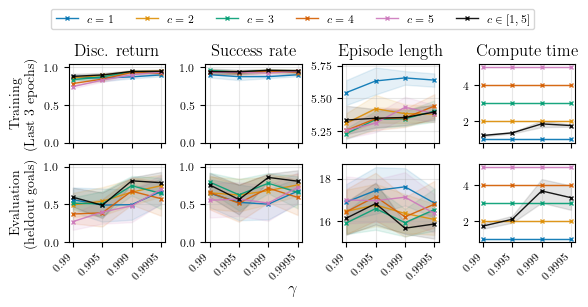

In [11]:
all_budget_labels = sorted(
    {
        budget_label(mn, mx)
        for mn, mx in df[["min_steps", "max_steps"]].drop_duplicates().itertuples(index=False)
    },
    key=lambda b: (b.startswith("adaptive"), b),
)
palette = dict(zip(all_budget_labels, sns.color_palette("colorblind", n_colors=len(all_budget_labels))))
palette["adaptive[1-5]"] = (0.0, 0.0, 0.0)

nrows = 2
ncols = 4

figsize = set_size(doc_width_pt, fraction=0.95, subplots=(nrows, ncols), use_golden_ratio=False)
fig, axes = plt.subplots(nrows, ncols, figsize=figsize, sharex=True, sharey=False)

axes = axes.flatten()
for col_i, (metric_to_plot, metric_name) in enumerate(zip(
    ("episode_discounted_return", "episode_return", "episode_length", "compute_time"),
    ("Disc. return", "Success rate", "Episode length", "Compute time"),
)):
    axes[col_i].set_title(metric_name)
    for metric_i, metric in enumerate(
        (f"actor/{metric_to_plot}/mean", f"absolute/{metric_to_plot}/mean")
    ):
        ax = axes[ncols * metric_i + col_i]
        curves = gamma_curves(df, metric, trim=TRIM_N)
        for budget, stats in curves.items():
            xrange = range(len(stats["gamma"]))
            # xrange = stats["gamma"]
            color = palette[budget]

            curr_label = budget
            if "uniform" in budget:
                curr_label = "$c = {}$".format(budget.split("=")[-1])
            elif "adaptive" in budget:
                splits = budget.split("[")[1].split("-")
                min_c = splits[0]
                max_c = splits[1][:-1]
                curr_label = "$c \\in [{}, {}]$".format(min_c, max_c)
            ax.plot(xrange, stats["mean"], marker="x", label=curr_label if col_i * metric_i == 0 else "", color=color, ms=3, linewidth=1, alpha=0.9)
            ax.fill_between(
                xrange, stats["mean"] - stats["ci"], stats["mean"] + stats["ci"], color=color, alpha=0.1
            )
        ax.set_xticks(xrange)
        if "return" in metric_to_plot:
            ax.set_ylim(0.0, 1.04)
        # ax.set_xticklabels([f"{g:g}" for g in gammas])
        ax.set_xticklabels([f"{g:g}" for g in gammas], rotation=45, ha="right")
        ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Training\n(Last {} epochs)".format(N_TAIL_EVALS))
axes[4].set_ylabel("Evaluation\n(heldout goals)")


handles, labels = axes[0].get_legend_handles_labels()
fig.supxlabel("$\\gamma$", y=0.1)
fig.legend(handles, labels, 
    bbox_to_anchor=(0.0, 1.0, 1.0, 0.0),
    loc="lower center",
    ncols=6,
    borderaxespad=0.0,
    frameon=True,
)
trim_suffix = f" (trim={TRIM_N})" if TRIM_N else ""
fig.tight_layout()
# fig.suptitle(f"{ARCH}: $\\gamma$ sensitivity{trim_suffix}")
# plt.show()
plt.savefig(f"analysis-gamma-all.pdf", dpi=600, format="pdf", bbox_inches="tight")